## Talent Acquisition Recruitment Performance Analysis
#### Analyzing recruitment funnel data across sourcing channels, recruiters, departments, properties, and locations for a hospitality organization, with the objective of identifying bottlenecks, key trends performance drivers, and opportunities to improve hiring quality, speed, and efficiency.

In [70]:
import pandas as pd
import numpy as np
import seaborn as sns

#### Importing Data

In [71]:
db = pd.read_excel(r"C:\Users\nikit\OneDrive\Desktop\New folder\TA Assignment\TA_Assignment.xlsx")

In [72]:
df = db.copy()

#### Exploring the Data

In [73]:
df.head()

,Candidate_ID,Req_ID,Application_Date,Source,Recruiter,Role_Category,Department,Property,Location,Hiring_Manager,...,Joined,Offer_Decline_Reason,Days_To_Screen,Days_To_Interview,Days_To_Offer,Days_To_Join,Salary_Band,Req_Open_Date,Req_Close_Date,Req_Ageing_Days
0,C0001,R103,2026-02-05,Walk-in,Aditi,Supervisory,F&B,Trident Gurgaon,Delhi NCR,Manager B,...,0,NaN,2,11,9,8,3-5L,2026-01-25,NaN,11
1,C0002,R112,2026-02-10,Naukri,Charu,Supervisory,Front Office,Oberoi Mumbai,Delhi NCR,Manager C,...,0,NaN,11,7,4,19,5-8L,2026-01-09,NaN,32
2,C0003,R148,2026-04-03,Referral,Charu,Supervisory,Front Office,Trident BKC,Mumbai,Manager C,...,0,NaN,10,7,6,10,3-5L,2026-02-21,NaN,41
3,C0004,R128,2026-03-04,Walk-in,Aditi,Supervisory,Front Office,Oberoi Delhi,Delhi NCR,Manager B,...,0,NaN,5,12,14,24,5-8L,2026-02-17,NaN,15
4,C0005,R151,2026-06-14,Referral,Charu,Frontline,Front Office,Trident Gurgaon,Mumbai,Manager B,...,0,NaN,10,15,9,25,3-5L,2026-05-11,NaN,34


In [74]:
df.shape

(700, 28)

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Candidate_ID          700 non-null    object        
 1   Req_ID                700 non-null    object        
 2   Application_Date      700 non-null    datetime64[ns]
 3   Source                700 non-null    object        
 4   Recruiter             700 non-null    object        
 5   Role_Category         700 non-null    object        
 6   Department            700 non-null    object        
 7   Property              700 non-null    object        
 8   Location              700 non-null    object        
 9   Hiring_Manager        700 non-null    object        
 10  Gender                700 non-null    object        
 11  Age_Band              700 non-null    object        
 12  Diversity_Category    700 non-null    object        
 13  Applied             

In [76]:
df.columns

Index(['Candidate_ID', 'Req_ID', 'Application_Date', 'Source', 'Recruiter',
       'Role_Category', 'Department', 'Property', 'Location', 'Hiring_Manager',
       'Gender', 'Age_Band', 'Diversity_Category', 'Applied', 'Screened',
       'Interviewed', 'Offered', 'Offer_Accepted', 'Joined',
       'Offer_Decline_Reason', 'Days_To_Screen', 'Days_To_Interview',
       'Days_To_Offer', 'Days_To_Join', 'Salary_Band', 'Req_Open_Date',
       'Req_Close_Date', 'Req_Ageing_Days'],
      dtype='object')

In [77]:
#data types of columns
df.dtypes

Candidate_ID                    object
Req_ID                          object
Application_Date        datetime64[ns]
Source                          object
Recruiter                       object
Role_Category                   object
Department                      object
Property                        object
Location                        object
Hiring_Manager                  object
Gender                          object
Age_Band                        object
Diversity_Category              object
Applied                          int64
Screened                         int64
Interviewed                      int64
Offered                          int64
Offer_Accepted                   int64
Joined                           int64
Offer_Decline_Reason            object
Days_To_Screen                   int64
Days_To_Interview                int64
Days_To_Offer                    int64
Days_To_Join                     int64
Salary_Band                     object
Req_Open_Date           d

In [78]:
#check for null values
df.isnull().sum()

Candidate_ID              0
Req_ID                    0
Application_Date          0
Source                    0
Recruiter                 0
Role_Category             0
Department                0
Property                  0
Location                  0
Hiring_Manager            0
Gender                    0
Age_Band                  0
Diversity_Category        0
Applied                   0
Screened                  0
Interviewed               0
Offered                   0
Offer_Accepted            0
Joined                    0
Offer_Decline_Reason    684
Days_To_Screen            0
Days_To_Interview         0
Days_To_Offer             0
Days_To_Join              0
Salary_Band               0
Req_Open_Date             0
Req_Close_Date          700
Req_Ageing_Days           0
dtype: int64

##### Offer Decline Reason is null for wherever no reason was mentioned for declining the offer, no offer made, or candidate joined
##### Req_Close_Date col is entirely empty, we have req_ageing_days which is the difference for open and close date, we can deop the column here

In [79]:
df = df.drop(columns = ['Req_Close_Date'])

In [80]:
df.columns

Index(['Candidate_ID', 'Req_ID', 'Application_Date', 'Source', 'Recruiter',
       'Role_Category', 'Department', 'Property', 'Location', 'Hiring_Manager',
       'Gender', 'Age_Band', 'Diversity_Category', 'Applied', 'Screened',
       'Interviewed', 'Offered', 'Offer_Accepted', 'Joined',
       'Offer_Decline_Reason', 'Days_To_Screen', 'Days_To_Interview',
       'Days_To_Offer', 'Days_To_Join', 'Salary_Band', 'Req_Open_Date',
       'Req_Ageing_Days'],
      dtype='object')

In [81]:
#check for duplicates
df.duplicated().sum()

np.int64(0)

### Exploratory Data Analysis

#### Unique Values in string columns

In [82]:
df[['Source', 'Recruiter', 'Role_Category', 'Department', 'Property', 'Location', 'Hiring_Manager', 'Gender', 'Age_Band', 'Diversity_Category', 
        'Salary_Band']]. apply(lambda x : x.unique())

Source                [Walk-in, Naukri, Referral, Social Media, Campus]
Recruiter                               [Aditi, Charu, Bhavesh, Deepak]
Role_Category                      [Supervisory, Frontline, Specialist]
Department            [F&B, Front Office, Engineering, Finance, Hous...
Property              [Trident Gurgaon, Oberoi Mumbai, Trident BKC, ...
Location                                 [Delhi NCR, Mumbai, Bangalore]
Hiring_Manager             [Manager B, Manager C, Manager A, Manager D]
Gender                                                   [Male, Female]
Age_Band                                   [25-30, 36-40, 31-35, 18-24]
Diversity_Category                            [Diversity Hire, General]
Salary_Band                                         [3-5L, 5-8L, 8-12L]
dtype: object

#### Numeric Columns

In [83]:
df[['Days_To_Screen', 'Days_To_Interview', 'Days_To_Offer', 'Days_To_Join', 'Req_Ageing_Days']].describe()

,Days_To_Screen,Days_To_Interview,Days_To_Offer,Days_To_Join,Req_Ageing_Days
count,700.000000,700.000000,700.000000,700.000000,700.000000
mean,5.734286,7.924286,10.465714,18.735714,25.250000
std,3.153801,3.490225,4.231866,6.817686,11.876646
min,1.000000,2.000000,3.000000,7.000000,5.000000
25%,3.000000,5.000000,7.000000,13.000000,14.750000
50%,6.000000,8.000000,11.000000,19.000000,25.000000
75%,8.000000,11.000000,14.000000,25.000000,35.250000
max,13.000000,16.000000,20.000000,30.000000,45.000000


#### Conversion Analysis - Recruitment Funnel

In [84]:
stage_col = df[['Applied', 'Screened', 'Interviewed', 'Offered', 'Offer_Accepted', 'Joined']]
stage_totals = stage_col.sum()
stage_totals

Applied           700
Screened          418
Interviewed       270
Offered           111
Offer_Accepted     95
Joined             93
dtype: int64

In [85]:
print("screened_pct =", (stage_totals['Screened'] / stage_totals['Applied'] * 100).round(2))
print("interviewed_pct =", (stage_totals['Interviewed'] / stage_totals['Screened'] * 100).round(2))
print("offered_pct =", (stage_totals['Offered'] / stage_totals['Interviewed'] * 100).round(2))
print("accepted_pct =", (stage_totals['Offer_Accepted'] / stage_totals['Offered'] * 100).round(2))
print("joined_pct =", (stage_totals['Joined'] / stage_totals['Offer_Accepted'] * 100).round(2))
print("offer_decline_pct =", ((stage_totals['Offered'] - stage_totals['Offer_Accepted'])/ stage_totals['Offered'] * 100).round(2))
print("drop_off_pct =", ((stage_totals['Offer_Accepted'] - stage_totals['Joined'])/ stage_totals['Offer_Accepted'] * 100).round(2))

screened_pct = 59.71
interviewed_pct = 64.59
offered_pct = 41.11
accepted_pct = 85.59
joined_pct = 97.89
offer_decline_pct = 14.41
drop_off_pct = 2.11


#### Since the lowest conversion we have is for Offered percentage (41.11 %) we will need to Analyse the Offered_pct (Interview to Offer) a step more in source

In [86]:
df1 = df.groupby('Source')[['Interviewed', 'Offered']].sum().reset_index()
df1['Conversion'] = (df1['Offered']/df1['Interviewed']* 100).round(2)
df1

,Source,Interviewed,Offered,Conversion
0,Campus,33,15,45.45
1,Naukri,103,38,36.89
2,Referral,54,25,46.30
3,Social Media,33,15,45.45
4,Walk-in,47,18,38.30


#### Looking at the converson the least is with Naukri as source the sample size here for other sources is relatively less which is impacting the converson, drilling this on recruiter basis too

In [87]:
df2 = df[df['Source'] == 'Naukri']
df2 = df2.groupby('Recruiter')[['Interviewed', 'Offered']].sum().reset_index()
df2['Conversion'] = (df2['Offered']/df2['Interviewed'] * 100).round(2)
df2

,Recruiter,Interviewed,Offered,Conversion
0,Aditi,25,5,20.00
1,Bhavesh,28,11,39.29
2,Charu,23,10,43.48
3,Deepak,27,12,44.44


In [88]:
df4 = df[df['Recruiter'] == 'Aditi']
df4 = df4.groupby('Source')[['Interviewed', 'Offered']].sum().reset_index()
df4['Conversion'] = (df4['Offered']/df4['Interviewed'] * 100).round(2)
df4

,Source,Interviewed,Offered,Conversion
0,Campus,11,6,54.55
1,Naukri,25,5,20.00
2,Referral,13,6,46.15
3,Social Media,13,7,53.85
4,Walk-in,14,5,35.71


##### With the numbers displayed we cannot rule out Naukri as a poor source of profiles considering almost double the profiles coming from Naukri, drilling further in Recruiter for Naukri makes Aditi stand out as poor performer but with every other source she has high conversion rate making the combination of Aditi with Naukri a poor contributor

In [89]:
df5 = df[df['Recruiter'] == 'Aditi']
df5 = df5.groupby('Hiring_Manager')[['Interviewed', 'Offered']].sum().reset_index()
df5['Conversion'] = (df5['Offered']/df5['Interviewed'] * 100).round(2)
df5

,Hiring_Manager,Interviewed,Offered,Conversion
0,Manager A,19,6,31.58
1,Manager B,13,6,46.15
2,Manager C,26,8,30.77
3,Manager D,18,9,50.00


##### Aditi's sourced interviews were further broken down by Hiring Manager. The conversion across managers varies on similar pattern but no single manager effects the overall pattern confirming that Aditi with Naukri combination itself, not hiring manager, is the driver of the drop-off.

### Hiring Success and Drop Offs

In [90]:
df['Offer_Decline_Reason'].value_counts().reset_index()

,Offer_Decline_Reason,count
0,Higher Salary,4
1,Role Fit,4
2,Location,3
3,No Response,3
4,Counter Offer,2


##### Only 16 candidates declined an offer, this is a small sample to draw a pattern. No dominant decline reason stands out for now

In [121]:
df1 = df.groupby('Source')[['Applied', 'Screened', 'Interviewed', 'Offered', 'Offer_Accepted', 'Joined']].sum()
df1['Offer_Acceptance'] = (df1['Offer_Accepted']/df1['Offered'] * 100).round(2)
df1['Joining_pct'] = (df1['Joined']/df1['Offer_Accepted'] * 100).round(2)
df1['Offer_Decline'] = ((df1['Offered'] - df1['Offer_Accepted'])/df1['Offered'] * 100).round(2)
df1['Drop_Off'] = ((df1['Offer_Accepted'] - df1['Joined'])/df1['Offer_Accepted'] * 100).round(2)
df1

,Applied,Screened,Interviewed,Offered,Offer_Accepted,Joined,Offer_Acceptance,Joining_pct,Offer_Decline,Drop_Off
Source,,,,,,,,,,
Campus,65,46,33,15,13,13,86.67,100.00,13.33,0.00
Naukri,301,168,103,38,34,32,89.47,94.12,10.53,5.88
Referral,91,82,54,25,21,21,84.00,100.00,16.00,0.00
Social Media,96,55,33,15,12,12,80.00,100.00,20.00,0.00
Walk-in,147,67,47,18,15,15,83.33,100.00,16.67,0.00


##### Offer decline by source is broadly consistent (10–20%) with no extreme outlier implementing that the Naukri finding is specific to the Interview to Offer stage and to Aditi, not a broader decline pattern

In [92]:
df2 = df.groupby('Recruiter')[['Applied', 'Screened', 'Interviewed', 'Offered', 'Offer_Accepted', 'Joined']].sum()
df2['Offer_Acceptance'] = (df2['Offer_Accepted']/df2['Offered'] * 100).round(2)
df2['Joining_pct'] = (df2['Joined']/df2['Offer_Accepted'] * 100).round(2)
df2['Offer_Decline'] = ((df2['Offered'] - df2['Offer_Accepted'])/df2['Offered'] * 100).round(2)
df2['Drop_Off'] = ((df2['Offer_Accepted'] - df2['Joined'])/df2['Offer_Accepted'] * 100).round(2)
df2

,Applied,Screened,Interviewed,Offered,Offer_Accepted,Joined,Offer_Acceptance,Joining_pct,Offer_Decline,Drop_Off
Recruiter,,,,,,,,,,
Aditi,194,107,76,29,25,25,86.21,100.00,13.79,0.00
Bhavesh,174,120,64,26,18,18,69.23,100.00,30.77,0.00
Charu,167,87,61,30,26,26,86.67,100.00,13.33,0.00
Deepak,165,104,69,26,26,24,100.00,92.31,0.00,7.69


##### Conversion and offer-decline patterns by Recruiter are broadly consistent, Aditi's overall numbers are in line with other recruiters, confirming that her performace is specific to the Naukri source rather than a general pattern. However the Offer Acceptance is significantally lowe for Bhavesh

In [93]:
df4 = df.groupby('Department')[['Applied', 'Screened', 'Interviewed', 'Offered', 'Offer_Accepted', 'Joined']].sum()
df4['Offer_Acceptance'] = (df4['Offer_Accepted']/df4['Offered'] * 100).round(2)
df4['Joining_pct'] = (df4['Joined']/df4['Offer_Accepted'] * 100).round(2)
df4['Offer_Decline'] = ((df4['Offered'] - df4['Offer_Accepted'])/df4['Offered'] * 100).round(2)
df4['Drop_Off'] = ((df4['Offer_Accepted'] - df4['Joined'])/df4['Offer_Accepted'] * 100).round(2)
df4

,Applied,Screened,Interviewed,Offered,Offer_Accepted,Joined,Offer_Acceptance,Joining_pct,Offer_Decline,Drop_Off
Department,,,,,,,,,,
Engineering,127,84,59,25,23,22,92.00,95.65,8.00,4.35
F&B,137,78,48,19,18,18,94.74,100.00,5.26,0.00
Finance,160,95,62,30,22,22,73.33,100.00,26.67,0.00
Front Office,131,75,50,23,19,18,82.61,94.74,17.39,5.26
Housekeeping,145,86,51,14,13,13,92.86,100.00,7.14,0.00


##### The Offer Acceptance rate for Finance is significantally lower however there ae no dropoffs in Finance, whereas comparing this to Engineering the offer accpetance is higher but the drop off is present as well

In [94]:
df5 = df.groupby('Location')[['Applied', 'Screened', 'Interviewed', 'Offered', 'Offer_Accepted', 'Joined']].sum()
df5['Offer_Acceptance'] = (df5['Offer_Accepted']/df5['Offered'] * 100).round(2)
df5['Joining_pct'] = (df5['Joined']/df5['Offer_Accepted'] * 100).round(2)
df5['Offer_Decline'] = ((df5['Offered'] - df5['Offer_Accepted'])/df5['Offered'] * 100).round(2)
df5['Drop_Off'] = ((df5['Offer_Accepted'] - df5['Joined'])/df5['Offer_Accepted'] * 100).round(2)
df5

,Applied,Screened,Interviewed,Offered,Offer_Accepted,Joined,Offer_Acceptance,Joining_pct,Offer_Decline,Drop_Off
Location,,,,,,,,,,
Bangalore,173,104,71,29,28,28,96.55,100.00,3.45,0.00
Delhi NCR,309,186,117,47,43,43,91.49,100.00,8.51,0.00
Mumbai,218,128,82,35,24,22,68.57,91.67,31.43,8.33


##### Mumbai stands out in the location as the offer decline is 31% which is quite above the Overall Offer Decline Pct of 14%

In [95]:
df6 = df.groupby('Property')[['Applied', 'Screened', 'Interviewed', 'Offered', 'Offer_Accepted', 'Joined']].sum()
df6['Offer_Acceptance'] = (df6['Offer_Accepted']/df6['Offered'] * 100).round(2)
df6['Joining_pct'] = (df6['Joined']/df6['Offer_Accepted'] * 100).round(2)
df6['Offer_Decline'] = ((df6['Offered'] - df6['Offer_Accepted'])/df6['Offered'] * 100).round(2)
df6['Drop_Off'] = ((df6['Offer_Accepted'] - df6['Joined'])/df6['Offer_Accepted'] * 100).round(2)
df6

,Applied,Screened,Interviewed,Offered,Offer_Accepted,Joined,Offer_Acceptance,Joining_pct,Offer_Decline,Drop_Off
Property,,,,,,,,,,
Oberoi Bangalore,138,81,50,23,18,17,78.26,94.44,21.74,5.56
Oberoi Delhi,137,75,45,23,19,19,82.61,100.00,17.39,0.00
Oberoi Mumbai,144,93,60,22,19,19,86.36,100.00,13.64,0.00
Trident BKC,137,75,50,16,15,14,93.75,93.33,6.25,6.67
Trident Gurgaon,144,94,65,27,24,24,88.89,100.00,11.11,0.00


##### Each Property is expected to map to a single city. However, in this dataset, every Property appears across all three Location values, suggesting Property and Location were populated independently rather than reflecting real geography. As a result, Property and Location are analysed here as two separate, independent dimensions rather 

### Diversity Trends Hiring

In [96]:
df7 = df.groupby('Diversity_Category')[['Applied', 'Screened', 'Interviewed', 'Offered', 'Offer_Accepted', 'Joined']].sum()
df7['Offer_Acceptance'] = (df7['Offer_Accepted']/df7['Offered'] * 100).round(2)
df7['Joining_pct'] = (df7['Joined']/df7['Offer_Accepted'] * 100).round(2)
df7['Offer_Decline'] = ((df7['Offered'] - df7['Offer_Accepted'])/df7['Offered'] * 100).round(2)
df7['Drop_Off'] = ((df7['Offer_Accepted'] - df7['Joined'])/df7['Offer_Accepted'] * 100).round(2)
df7

,Applied,Screened,Interviewed,Offered,Offer_Accepted,Joined,Offer_Acceptance,Joining_pct,Offer_Decline,Drop_Off
Diversity_Category,,,,,,,,,,
Diversity Hire,370,220,154,63,52,51,82.54,98.08,17.46,1.92
General,330,198,116,48,43,42,89.58,97.67,10.42,2.33


##### Diversity Hires interview and get offered at rates similar to General candidates, but offer decline is considerably higher.

In [97]:
df8 = df.groupby('Gender')[['Applied', 'Screened', 'Interviewed', 'Offered', 'Offer_Accepted', 'Joined']].sum()
df8['Offer_Acceptance'] = (df8['Offer_Accepted']/df8['Offered'] * 100).round(2)
df8['Joining_pct'] = (df8['Joined']/df8['Offer_Accepted'] * 100).round(2)
df8['Offer_Decline'] = ((df8['Offered'] - df8['Offer_Accepted'])/df8['Offered'] * 100).round(2)
df8['Drop_Off'] = ((df8['Offer_Accepted'] - df8['Joined'])/df8['Offer_Accepted'] * 100).round(2)
df8

,Applied,Screened,Interviewed,Offered,Offer_Accepted,Joined,Offer_Acceptance,Joining_pct,Offer_Decline,Drop_Off
Gender,,,,,,,,,,
Female,340,209,126,49,42,42,85.71,100.00,14.29,0.00
Male,360,209,144,62,53,51,85.48,96.23,14.52,3.77


In [98]:
df9 = df.groupby('Age_Band')[['Applied', 'Screened', 'Interviewed', 'Offered', 'Offer_Accepted', 'Joined']].sum()
df9['Offer_Acceptance'] = (df9['Offer_Accepted']/df9['Offered'] * 100).round(2)
df9['Joining_pct'] = (df9['Joined']/df9['Offer_Accepted'] * 100).round(2)
df9['Offer_Decline'] = ((df9['Offered'] - df9['Offer_Accepted'])/df9['Offered'] * 100).round(2)
df9['Drop_Off'] = ((df9['Offer_Accepted'] - df9['Joined'])/df9['Offer_Accepted'] * 100).round(2)
df9

,Applied,Screened,Interviewed,Offered,Offer_Accepted,Joined,Offer_Acceptance,Joining_pct,Offer_Decline,Drop_Off
Age_Band,,,,,,,,,,
18-24,163,104,68,21,20,20,95.24,100.0,4.76,0.0
25-30,176,117,73,36,30,30,83.33,100.0,16.67,0.0
31-35,178,96,61,24,20,20,83.33,100.0,16.67,0.0
36-40,183,101,68,30,25,23,83.33,92.0,16.67,8.0


##### The Offer decline percentage for all age groups is around the overall percentage but the decline percentage is only 4.76% for 18-24 group

#### Analysing Speed

##### Since we checked there are no null values in any Days column that is an anomaly as people who were never offered also have values in Days to Join column same for others as well we will analyse this

In [99]:
df[df['Screened'] == 0]['Days_To_Screen'].describe()

count    282.000000
mean       6.141844
std        3.175936
min        1.000000
25%        3.000000
50%        6.000000
75%        8.000000
max       13.000000
Name: Days_To_Screen, dtype: float64

In [100]:
df.loc[df['Screened'] == 0, 'Days_To_Screen'] = None

In [101]:
df[df['Screened'] == 0]['Days_To_Screen'].describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Days_To_Screen, dtype: float64

In [102]:
df[df['Interviewed'] == 0]['Days_To_Interview'].describe()

count    430.000000
mean       7.944186
std        3.462978
min        2.000000
25%        5.000000
50%        8.000000
75%       11.000000
max       16.000000
Name: Days_To_Interview, dtype: float64

In [103]:
df.loc[df['Interviewed'] == 0, 'Days_To_Interview'] = None

In [104]:
df[df['Offered'] == 0]['Days_To_Offer'].describe()

count    589.000000
mean      10.402377
std        4.218044
min        3.000000
25%        7.000000
50%       10.000000
75%       13.000000
max       20.000000
Name: Days_To_Offer, dtype: float64

In [105]:
df.loc[df['Offered'] == 0, 'Days_To_Offer'] = None

In [106]:
df[df['Joined'] == 0]['Days_To_Join'].describe()

count    607.000000
mean      18.812191
std        6.870152
min        7.000000
25%       13.000000
50%       19.000000
75%       25.000000
max       30.000000
Name: Days_To_Join, dtype: float64

In [107]:
df.loc[df['Joined'] == 0, 'Days_To_Join'] = None

In [109]:
df.groupby('Source')[['Days_To_Screen','Days_To_Interview','Days_To_Offer','Days_To_Join']].mean().round(2)

,Days_To_Screen,Days_To_Interview,Days_To_Offer,Days_To_Join
Source,,,,
Campus,5.28,7.82,9.60,18.31
Naukri,5.46,8.47,10.42,19.22
Referral,5.73,8.46,12.04,19.90
Social Media,5.44,6.42,10.47,16.92
Walk-in,5.25,7.06,11.17,14.80


In [110]:
df.groupby('Recruiter')[['Days_To_Screen','Days_To_Interview','Days_To_Offer','Days_To_Join']].mean().round(2)

,Days_To_Screen,Days_To_Interview,Days_To_Offer,Days_To_Join
Recruiter,,,,
Aditi,4.07,6.86,10.45,17.16
Bhavesh,4.41,7.03,9.96,18.44
Charu,9.51,10.66,10.83,17.85
Deepak,4.72,7.39,12.00,19.62


In [111]:
df.groupby('Department')[['Days_To_Screen','Days_To_Interview','Days_To_Offer','Days_To_Join']].mean().round(2)

,Days_To_Screen,Days_To_Interview,Days_To_Offer,Days_To_Join
Department,,,,
Engineering,5.45,8.07,10.00,17.86
F&B,5.14,8.17,11.26,19.56
Finance,5.26,7.44,11.03,16.27
Front Office,5.75,8.12,11.35,20.33
Housekeeping,5.72,7.76,10.21,17.46


#### Req Ageing Days

In [112]:
df.groupby('Source')['Req_Ageing_Days'].mean().round(2).reset_index()

,Source,Req_Ageing_Days
0,Campus,25.34
1,Naukri,25.17
2,Referral,27.56
3,Social Media,24.95
4,Walk-in,24.15


In [113]:
df.groupby('Recruiter')['Req_Ageing_Days'].mean().round(2).reset_index()

,Recruiter,Req_Ageing_Days
0,Aditi,24.90
1,Bhavesh,24.44
2,Charu,26.34
3,Deepak,25.42


In [114]:
df.groupby('Department')['Req_Ageing_Days'].mean().round(2).reset_index()

,Department,Req_Ageing_Days
0,Engineering,23.69
1,F&B,26.22
2,Finance,25.95
3,Front Office,25.31
4,Housekeeping,24.88


In [115]:
df.groupby('Property')['Req_Ageing_Days'].mean().round(2).reset_index()

,Property,Req_Ageing_Days
0,Oberoi Bangalore,24.72
1,Oberoi Delhi,25.00
2,Oberoi Mumbai,26.21
3,Trident BKC,24.95
4,Trident Gurgaon,25.33


In [116]:
df.groupby('Location')['Req_Ageing_Days'].mean().round(2).reset_index()

,Location,Req_Ageing_Days
0,Bangalore,24.54
1,Delhi NCR,26.53
2,Mumbai,23.99


In [117]:
# Exporting Clean Data

df.to_excel(r'C:\Users\nikit\OneDrive\Desktop\New folder\TA Assignment\TA Assignment Cleaned Data.xlsx', index = False)

### Correlation

In [118]:
df['Req_Ageing_Days'].corr(df['Days_To_Join'])

np.float64(0.037365418117906404)

<Axes: >

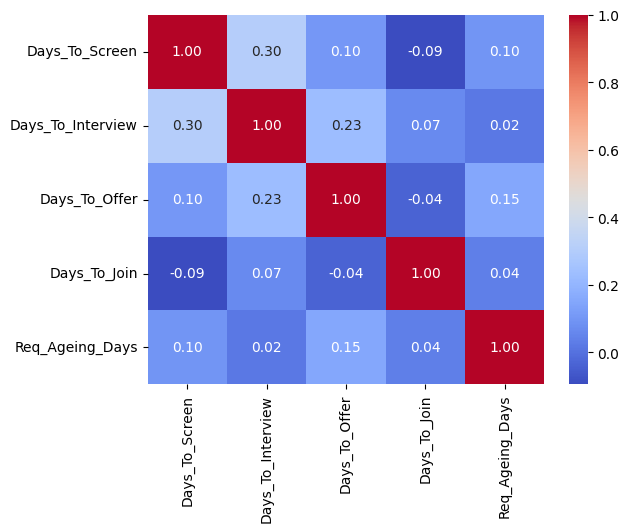

In [119]:
corr_cols = ['Days_To_Screen', 'Days_To_Interview', 'Days_To_Offer', 'Days_To_Join', 'Req_Ageing_Days']
corr_matrix = df[corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')

##### Correlations across stage-to-stage metrics is weak (max 0.30, Days_To_Screen–Days_To_Interview), indicating each funnel stage's speed is largely independent

### Predictive Analysis

#### The gap we found earlier, Aditi converting only 20% of Naukri candidates to offers, versus around 42% for other recruiters, is based on a small number of interviews (25). With small numbers, this gap may happen sometimes by chance, not because something is actually different. This check compares what we actually saw against what we expect if every recruiter converted at roughly the same rate, to see how likely it is that this gap is just random luck rather than a real pattern.

In [127]:
from scipy.stats import chi2_contingency

naukri = df[df['Source'] == 'Naukri']
contingency = pd.crosstab(naukri['Recruiter'], naukri['Offered'])
chi2, p, dof, expected = chi2_contingency(contingency)

print("p-value:", round(p, 4))

p-value: 0.1986


##### The result (p = 0.1986) is not low enough to rule out chance, most likely because the sample is small. The pattern is still worth looking into, but it should be treated as a lead to investigate rather than a confirmed issue.

### Summary of Key Findings

##### Funnel bottleneck: Interview to Offer is the highest drop-off stage (41.11% conversion); later stages (Offer Acceptance 85.59%, Joining 97.89%) remain strong.

##### Source-recruiter interaction: Naukri shows the lowest Interview to Offer conversion among sources (36.89%), concentrated specifically in candidate handled by recruiter Aditi (20.00% within Naukri) — confirmed not explained by Hiring Manager assignment, and not a general recruiter-performance issue since Aditi perfoms well across every other source.

##### Speed: Stage-to-stage processing times are weakly correlated (max 0.30) and largely independent of requisition ageing (0.037 correlation) 

##### Data quality: Req_Close_Date dropped (100% null); all four Days_To_X columns corrected for invalid values on candidates who never reached that stage; Property and Location treated as independent dimensions due to inconsistent mapping in the source data.